<a href="https://colab.research.google.com/github/alimohmedelsaid26-cell/1000MLEngineer/blob/main/Handwritten_Digit_Recognition_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
 1.#Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from google.colab.patches import cv2_imshow
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.math import confusion_matrix
# Set seed for reproducibility
tf.random.set_seed(3)

In [35]:
# 2. Data Loading & Advanced Preprocessing

# Load MNIST dataset
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()
# shape of the numpy arrays
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [41]:
#printing the 10th image

print(X_train[10])

[[[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [ 42]


In [40]:
# Reshape data for CNN (Adding the 1 channel for grayscale)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

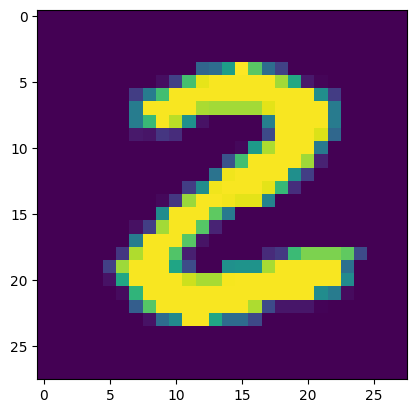

2


In [47]:
# displaying the image

plt.imshow(X_train[25])
plt.show()

# print the corresponding label
print(Y_train[25])

In [48]:
# unique values in Y_train
print(np.unique(Y_train))

# unique values in Y_test
print(np.unique(Y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


In [45]:
 #Normalization (Scaling pixel values between 0 and 1)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# One-Hot Encoding for labels (0 becomes [1,0,0...], 1 becomes [0,1,0...])
Y_train_cat = to_categorical(Y_train, 10)
Y_test_cat = to_categorical(Y_test, 10)

In [46]:
#printing the 10th image

print(X_train[10])

[[[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0. 

In [29]:
 3.#Data Augmentation Engine
# This generates variations of the images (rotated, zoomed)
# so the model learns to recognize digits in any position.
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(X_train)

In [31]:
 4.#Building the CNN Architecture

model = models.Sequential([
    # First Convolutional Layer + Pooling
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Layer + Pooling
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    # Fully Connected Layer with Dropout to prevent Overfitting
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    # Output Layer with Softmax for multi-class probability
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [49]:
 5.#Model Training

print("\n--- Starting Advanced Training with Data Augmentation ---")
history = model.fit(datagen.flow(X_train, Y_train_cat, batch_size=32),
                    epochs=10,
                    validation_data=(X_test, Y_test_cat))


--- Starting Advanced Training with Data Augmentation ---
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - accuracy: 0.9878 - loss: 0.0394 - val_accuracy: 0.9944 - val_loss: 0.0194
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - accuracy: 0.9887 - loss: 0.0384 - val_accuracy: 0.9921 - val_loss: 0.0225
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.9888 - loss: 0.0372 - val_accuracy: 0.9933 - val_loss: 0.0194
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.9892 - loss: 0.0345 - val_accuracy: 0.9903 - val_loss: 0.0336
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 24ms/step - accuracy: 0.9898 - loss: 0.0335 - val_accuracy: 0.9934 - val_loss: 0.0219
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9898 - loss: 0.0344 - val_accuracy: 0.9921 - val_loss: 0.0246
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.9901 - loss: 0.0330 - val_accuracy: 0.9934 - val_loss: 0.0207
Epoch 8/10
1875/1

In [50]:
# 6. Evaluation & Confusion Matrix
# ---------------------------------------------------------

# Final accuracy check
loss, accuracy = model.evaluate(X_test, Y_test_cat)
print(f"\nFinal Test Accuracy: {accuracy*100:.2f}%")

# Generate Confusion Matrix
Y_pred = model.predict(X_test)
Y_pred_labels = [np.argmax(i) for i in Y_pred]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9926 - loss: 0.0233

Final Test Accuracy: 99.26%
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [51]:
print(X_test.shape)

(10000, 28, 28, 1)


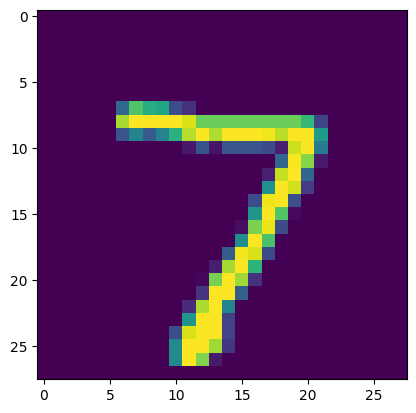

In [52]:
# first data point in X_test
plt.imshow(X_test[0])
plt.show()

In [53]:
print(Y_test[0])

7


In [54]:
Y_pred = model.predict(X_test)
print(Y_pred.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
(10000, 10)


In [55]:
print(Y_pred[0])

[3.2324251e-14 4.9838387e-11 6.5498625e-06 4.2200070e-09 2.6688449e-09
 8.2972448e-12 2.8074608e-16 9.9999338e-01 1.1066323e-11 3.1327367e-09]


In [56]:
# converting the prediction probabilities to class label

label_for_first_test_image = np.argmax(Y_pred[0])
print(label_for_first_test_image)

7


In [57]:
# converting the prediction probabilities to class label for all test data points
Y_pred_labels = [np.argmax(i) for i in Y_pred]
print(Y_pred_labels)

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(3), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(3), np.int64(7), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

In [58]:
conf_mat = confusion_matrix(Y_test, Y_pred_labels)

In [59]:
print(conf_mat)

tf.Tensor(
[[ 975    0    2    1    0    0    1    0    1    0]
 [   1 1122    0    2    4    0    1    3    2    0]
 [   1    1 1024    1    0    0    0    4    1    0]
 [   0    0    0 1009    0    1    0    0    0    0]
 [   0    0    1    0  981    0    0    0    0    0]
 [   0    0    0    6    0  885    1    0    0    0]
 [   2    1    0    0    3    2  949    0    1    0]
 [   0    2    2    0    0    0    0 1022    1    1]
 [   0    0    1    0    0    1    0    1  971    0]
 [   0    0    1    0   12    2    0    3    3  988]], shape=(10, 10), dtype=int32)


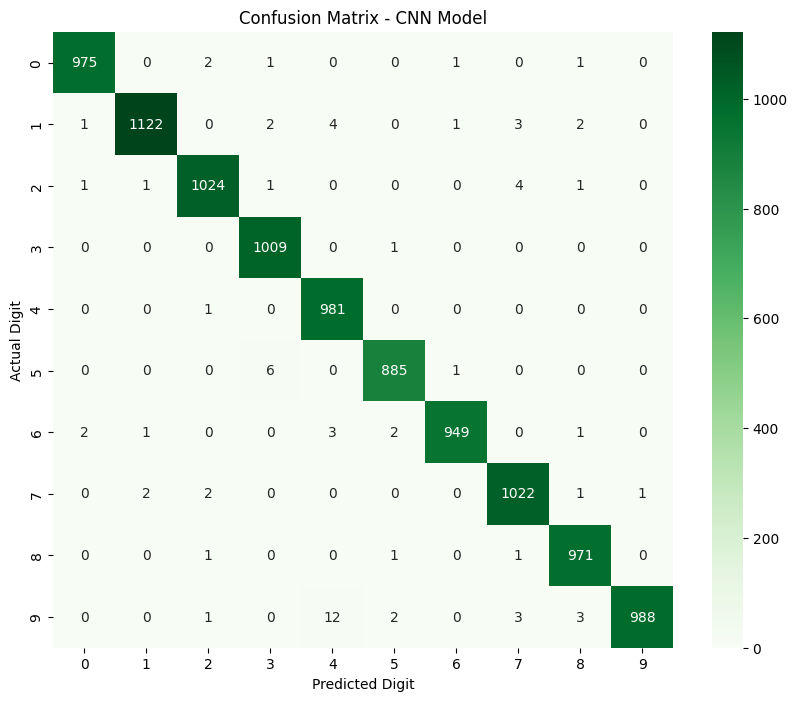

In [60]:

conf_mat = confusion_matrix(Y_test, Y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - CNN Model')
plt.xlabel('Predicted Digit')
plt.ylabel('Actual Digit')
plt.show()